## Import libs

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.data import Dataset
import seaborn as sns


from models.unfair_lr.models import UnfairLogisticRegression
from models.unfair_lr.learning import train_loop
from util.evaluation import *
from util.load_data import load_data

/Users/lffpl/Projects/falsb/env/falsb/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Preliminaries

In [2]:
batch_size = 64
epochs = 100
lr = 0.001

In [3]:
cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'arrhythmia-age'

In [5]:
x, y, a = load_data(data_name)
raw_data = (x, y, a)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
adim = a.shape[1]
zdim = 8

In [7]:
print(xdim, ydim, adim)
print(len(x))

278 1 1
420


## Result file

In [8]:
header = "model_name", "cv_seed", "clas_acc", "dp", "deqodds", "deqopp", "trade_dp", "trade_deqodds", "trade_deqopp", "TN_a0", "FP_a0", "FN_a0", "TP_a0", "TN_a1", "FP_a1", "FN_a1", "TP_a1"
results = []

## Testing

In [9]:
for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a_train, a_test = train_test_split(
        x, y, a, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    # train below

    model = UnfairLogisticRegression(xdim, ydim, batch_size)
    ret = train_loop(model, train_data, epochs)
    Y, A, Y_hat = evaluation(model, test_data)
    
    clas_acc, dp, deqodds, deqopp, confusion_matrix, metrics_a0, metrics_a1  = compute_metrics(Y, A, Y_hat, adim=adim)
    
    fair_metrics = (dp, deqodds, deqopp)
    
    tradeoff = []
    
    for fair_metric in fair_metrics:
        tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
    
    result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    results.append(result)

> Epoch | Class Loss | Class Acc
> 1 | 0.7792036533355713 | 0.5625
> 2 | 0.7470400929450989 | 0.5625
> 3 | 0.7327455282211304 | 0.5625


2026-01-05 15:22:39.142905: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-05 15:22:39.195946: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-05 15:22:39.302515: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 4 | 0.724732518196106 | 0.5625
> 5 | 0.7196714878082275 | 0.5625
> 6 | 0.7161996364593506 | 0.5625
> 7 | 0.7136626243591309 | 0.5625
> 8 | 0.7117198705673218 | 0.5625


2026-01-05 15:22:39.494761: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 9 | 0.710176944732666 | 0.5625
> 10 | 0.7089158296585083 | 0.5625
> 11 | 0.7078612446784973 | 0.5625
> 12 | 0.7069625854492188 | 0.5625
> 13 | 0.7061847448348999 | 0.5625
> 14 | 0.7055028676986694 | 0.5625
> 15 | 0.7048982381820679 | 0.5625
> 16 | 0.7043571472167969 | 0.5625


...

> 68 | 0.696265697479248 | 0.5625
> 69 | 0.6962063312530518 | 0.5625
> 70 | 0.6961479783058167 | 0.5625
> 71 | 0.6960906982421875 | 0.5625
> 72 | 0.6960344314575195 | 0.5625
> 73 | 0.6959791779518127 | 0.5625
> 74 | 0.6959248781204224 | 0.5625
> 75 | 0.6958714723587036 | 0.5625
> 76 | 0.6958190202713013 | 0.5625
> 77 | 0.6957675218582153 | 0.5625
> 78 | 0.6957178115844727 | 0.5625
> 79 | 0.6956688761711121 | 0.5625
> 80 | 0.6956207752227783 | 0.5625
> 81 | 0.6955733299255371 | 0.5625
> 82 | 0.6955265998840332 | 0.5625
> 83 | 0.6954806447029114 | 0.5625
> 84 | 0.6954353451728821 | 0.5625
> 85 | 0.6953907012939453 | 0.5625
> 86 | 0.6953467130661011 | 0.5625
> 87 | 0.6953033208847046 | 0.5625
> 88 | 0.6952605247497559 | 0.5625
> 89 | 0.6952183842658997 | 0.5625
> 90 | 0.6951768398284912 | 0.5625
> 91 | 0.6951358318328857 | 0.5625
> 92 | 0.6950953006744385 | 0.5625
> 93 | 0.695055365562439 | 0.5625
> 94 | 0.6950159668922424 | 0.5625
> 95 | 0.6949770450592041 | 0.5625
> 96 | 0.6949386000633

2026-01-05 15:22:46.309111: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 30 | 0.6808760762214661 | 0.5625
> 31 | 0.6807721257209778 | 0.5625
> 32 | 0.6806724667549133 | 0.5625
> 33 | 0.6805766820907593 | 0.5625
> 34 | 0.6804844737052917 | 0.5625
> 35 | 0.6803956031799316 | 0.5625
> 36 | 0.6803098917007446 | 0.5625
> 37 | 0.6802270412445068 | 0.5625
> 38 | 0.6801469922065735 | 0.5625
> 39 | 0.6800693869590759 | 0.5625
> 40 | 0.6799942255020142 | 0.5625
> 41 | 0.6799212694168091 | 0.5625
> 42 | 0.6798503994941711 | 0.5625
> 43 | 0.6797814965248108 | 0.5625
> 44 | 0.679714560508728 | 0.5625
> 45 | 0.6796493530273438 | 0.5625
> 46 | 0.6795858144760132 | 0.5625
> 47 | 0.6795239448547363 | 0.5625
> 48 | 0.6794635653495789 | 0.5625
> 49 | 0.6794046759605408 | 0.5625
> 50 | 0.6793471574783325 | 0.5625
> 51 | 0.6792908906936646 | 0.5625
> 52 | 0.6792359352111816 | 0.5625
> 53 | 0.6791821718215942 | 0.5625
> 54 | 0.6791296005249023 | 0.5625
> 55 | 0.6790780425071716 | 0.5625
> 56 | 0.6790275573730469 | 0.5625
> 57 | 0.6789780855178833 | 0.5625
> 58 | 0.678929686546

2026-01-05 15:22:53.856377: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 57 | 0.6778451204299927 | 0.57421875
> 58 | 0.6777974367141724 | 0.57421875
> 59 | 0.6777507066726685 | 0.57421875
> 60 | 0.6777046918869019 | 0.57421875
> 61 | 0.6776595115661621 | 0.57421875
> 62 | 0.6776150465011597 | 0.57421875
> 63 | 0.6775713562965393 | 0.57421875
> 64 | 0.6775283217430115 | 0.57421875
> 65 | 0.6774859428405762 | 0.57421875
> 66 | 0.6774442791938782 | 0.57421875
> 67 | 0.6774032115936279 | 0.57421875
> 68 | 0.6773627996444702 | 0.57421875
> 69 | 0.6773229837417603 | 0.57421875
> 70 | 0.6772837042808533 | 0.57421875
> 71 | 0.677245020866394 | 0.57421875
> 72 | 0.6772069334983826 | 0.57421875
> 73 | 0.6771693229675293 | 0.57421875
> 74 | 0.677132248878479 | 0.57421875
> 75 | 0.6770955920219421 | 0.57421875
> 76 | 0.677059531211853 | 0.57421875
> 77 | 0.6770239472389221 | 0.57421875
> 78 | 0.6769888401031494 | 0.57421875
> 79 | 0.6769541501998901 | 0.57421875
> 80 | 0.6769198179244995 | 0.57421875
> 81 | 0.6768861413002014 | 0.57421875
> 82 | 0.6768527030944824 | 

<Axes: >

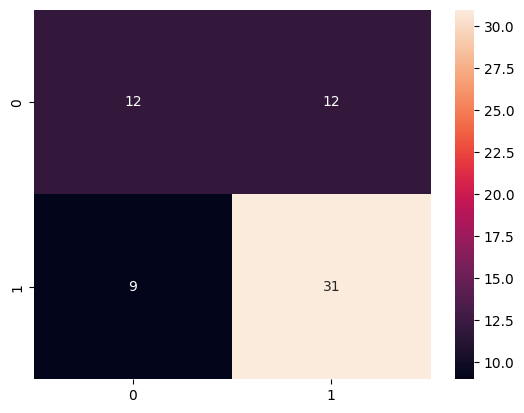

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

In [11]:
for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a_train, a_test = train_test_split(
        x, y, a, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    # train below

    opt = Adam(learning_rate=lr)

    model = UnfairLogisticRegression(xdim, ydim, batch_size)
    ret = train_loop(model, train_data, epochs, opt)
    Y, A, Y_hat = evaluation(model, test_data)
    
    clas_acc, dp, deqodds, deqopp, confusion_matrix, metrics_a0, metrics_a1  = compute_metrics(Y, A, Y_hat, adim=adim)
    
    fair_metrics = (dp, deqodds, deqopp)
    
    tradeoff = []
    
    for fair_metric in fair_metrics:
        tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
    
    result = ['UnfairLR', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    results.append(result)

    del(opt)

> Epoch | Class Loss | Class Acc
> 1 | 0.7792036533355713 | 0.5625
> 2 | 0.730783998966217 | 0.5625
> 3 | 0.7034959197044373 | 0.5625
> 4 | 0.6910568475723267 | 0.5625
> 5 | 0.6855849027633667 | 0.58984375
> 6 | 0.6829129457473755 | 0.59375
> 7 | 0.6821632981300354 | 0.578125
> 8 | 0.6827988028526306 | 0.5703125
> 9 | 0.683436930179596 | 0.56640625


2026-01-05 15:23:08.765020: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 10 | 0.6825879812240601 | 0.56640625
> 11 | 0.6796808242797852 | 0.56640625
> 12 | 0.6752151250839233 | 0.56640625
> 13 | 0.6701651811599731 | 0.58203125
> 14 | 0.6653496026992798 | 0.5859375
> 15 | 0.6611756086349487 | 0.609375
> 16 | 0.6577001810073853 | 0.6171875
> 17 | 0.6547783017158508 | 0.625
> 18 | 0.6521751880645752 | 0.6328125
> 19 | 0.6496466994285583 | 0.640625
> 20 | 0.6470085382461548 | 0.64453125
> 21 | 0.6441826820373535 | 0.65234375
> 22 | 0.6411951780319214 | 0.66015625
> 23 | 0.6381345391273499 | 0.66796875
> 24 | 0.6350980997085571 | 0.671875
> 25 | 0.632154107093811 | 0.6796875
> 26 | 0.629329264163971 | 0.68359375
> 27 | 0.6266140341758728 | 0.6875
> 28 | 0.6239783763885498 | 0.69140625
> 29 | 0.6213886737823486 | 0.69921875
> 30 | 0.6188197731971741 | 0.70703125
> 31 | 0.61626136302948 | 0.70703125
> 32 | 0.6137155294418335 | 0.7109375
> 33 | 0.6111925840377808 | 0.71484375
> 34 | 0.6087038516998291 | 0.71484375
> 35 | 0.6062573194503784 | 0.71484375
> 36 | 0.6

<Axes: >

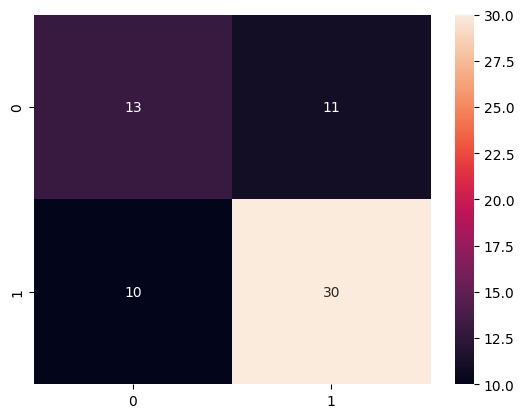

In [12]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [13]:
result_df = pd.DataFrame(results, columns=header)
result_df

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
0,UnfairLR-decay,13,0.453125,1.000000,1.000000,1.000000,0.623656,0.623656,0.623656,0.0,27.0,0.0,19.0,0.0,8.0,0.0,10.0
1,UnfairLR-decay,29,0.640625,1.000000,1.000000,1.000000,0.780952,0.780952,0.780952,0.0,14.0,0.0,22.0,0.0,9.0,0.0,19.0
2,UnfairLR-decay,42,0.406250,1.000000,1.000000,1.000000,0.577778,0.577778,0.577778,0.0,22.0,0.0,18.0,0.0,16.0,0.0,8.0
3,UnfairLR-decay,55,0.531250,1.000000,1.000000,1.000000,0.693878,0.693878,0.693878,0.0,17.0,0.0,18.0,0.0,13.0,0.0,16.0
4,UnfairLR-decay,73,0.671875,0.942690,0.770655,0.763533,0.784570,0.717883,0.714777,10.0,8.0,4.0,23.0,2.0,4.0,5.0,8.0
5,UnfairLR,13,0.578125,0.772947,0.733577,0.957895,0.661489,0.646640,0.721062,7.0,20.0,3.0,16.0,6.0,2.0,2.0,8.0
6,UnfairLR,29,0.796875,0.873016,0.881655,0.961722,0.833210,0.837124,0.871572,9.0,5.0,2.0,20.0,4.0,5.0,1.0,18.0
7,UnfairLR,42,0.687500,0.883333,0.934028,0.930556,0.773210,0.792024,0.790773,11.0,11.0,1.0,17.0,9.0,7.0,1.0,7.0
8,UnfairLR,55,0.640625,0.843350,0.835957,0.798611,0.728140,0.725371,0.710947,7.0,10.0,2.0,16.0,7.0,6.0,5.0,11.0
9,UnfairLR,73,0.671875,0.938012,0.818376,0.914530,0.782945,0.737925,0.774644,11.0,7.0,6.0,21.0,2.0,4.0,4.0,9.0


In [14]:
result_df.to_csv(f'{data_name}-result/unfair_lr-{epochs}.csv')